### **UNIVERSIDADE FEDERAL DE ITAJUBÁ**
### **Instituto de Matemática e Computação**
### **Ciência da Computação**

--

### **XMCO09 - Ciência de Redes**

### **Tópico: 2. Propriedades Gerais das Redes**

## **Atividade 2 (AT2)**

---

**Objetivo:** Neste notebook, você vai aprender a carregar arquivos de datasets de redes e a explorar algumas de suas propriedades básicas. Essas atividades fazem parte das primeiras etapas do processo de análise de redes, servindo como ponto de partida para estudos mais avançados. Para cada enunciado a seguir implemente os códigos de modo a atender o que se pede.

---

## **0. Bibliotecas e Entrada de Dados**

É recomendável adicionar as bibliotecas necessárias logo no início do código. **Obs**: Use a célula abaixo para as bibliotecas que forem necessárias.

**Q1.** Instales biliotecas iGraph (https://python.igraph.org/en/stable/) e Matplotlib (https://matplotlib.org/).

**Q2.** Importe as seguintes bibliotecas: *numpy, time, math, igraph, matplotlib, google.colab (drive)*. Faça a montagem de uma pasta no repositório do Google Drive que contenha os *datasets* sobre redes que serão usados para análises.

In [37]:
import sys
sys.path.insert(0, "..")

import numpy as np
import time
import math
import igraph as ig
import matplotlib.pyplot as plt

from methods.similarity import common_aisles, common_items
from process.dataset import Problem
from process.graph import Graph

**Q3.** Implemente uma função que recebe como entrada o nome de um *dataset* armazenado no seu Google Drive (ex. zachary), lê o respectivo arquivo .txt, atribua o conteúdo do arquivo a um objeto tipo `numpy.ndarray`, imprime na tela a respectiva Matriz de Adjacências.

In [38]:
instance = input("Enter the instance name (e.g., 'instance_0001.txt'): ")
problem = Problem("../../dataset/" + instance)
graph = Graph(problem, common_aisles)

adjMatrix = np.array(graph.g.get_adjacency(attribute="weight"))
print("Adjacency Matrix:")
print(adjMatrix)

Adjacency Matrix:
[[0.  0.8 0.8 0.8 0.8]
 [0.8 0.  1.  1.  1. ]
 [0.8 1.  0.  1.  1. ]
 [0.8 1.  1.  0.  1. ]
 [0.8 1.  1.  1.  0. ]]


**Q4.** Crie uma função que verifique se a matriz corresponde a uma rede não-direcionada (U = undirected) ou direcionada (D = directed). A função deverá retornar uma string 'undirected' ou 'directed'.

In [39]:
def verify_simetry(matrix):
    if ((matrix != matrix.T).any()):
        return 'directed'
    else:
        return 'undirected'

network_type = verify_simetry(adjMatrix)
print(network_type)

undirected


**Q5.** Crie um objeto do tipo Graph (igraph) para representar a rede da matriz de adjacências dada como entrada. Plote a rede com o layout à sua escolha, identifique unicamente os nós com um número inteiro. **OBS.** garanta que o grafo (igraph.Graph) seja do tipo correto para representar a rede como não-dirigida (U = 'undirected') ou dirigida (D = 'directed').

IGRAPH U-W- 5 10 --
+ attr: weight (e)
+ edges:
0 -- 1 2 3 4   1 -- 0 2 3 4   2 -- 0 1 3 4   3 -- 0 1 2 4   4 -- 0 1 2 3


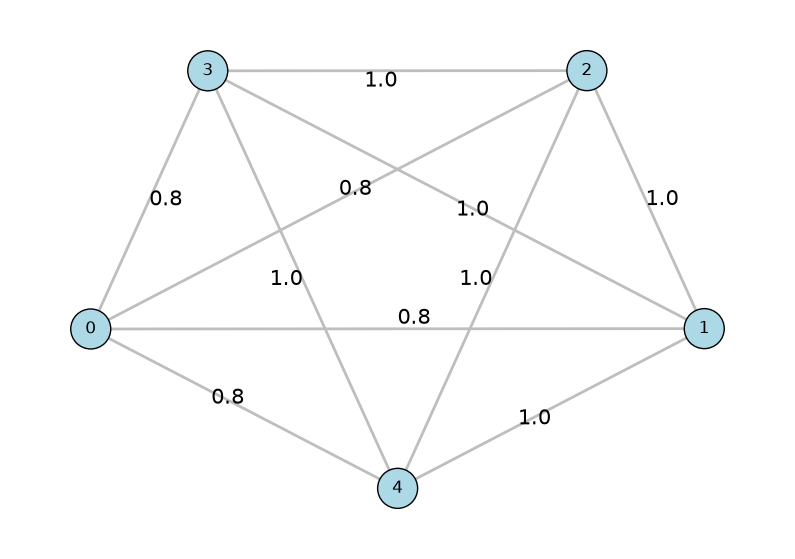

In [40]:
print(graph.g)
graph.g.vs["label"] = [str(o) for o in range(problem.o)]

fig, ax = plt.subplots(figsize=(10, 7))

ig.plot(
    graph.g,
    target=ax,
    layout= "fr",
    vertex_size=40,
    vertex_color="lightblue",
    vertex_label=graph.g.vs["label"],
    edge_color="gray",
    edge_label=graph.g.es["weight"],
    edge_label_size=15,
    edge_label_color="black",
    bbox= (800, 600)
    )

---

## **1. Características Morfológicas do Grafo**

**Q6.** Obtenha a quantidade de nós, quantidade de links (rede original e completa) e densidade da rede.

In [41]:
print('Qtd. Nós =', graph.g.vcount())
print('Qtd. Links (Original) =', graph.g.ecount())
print('Qtd. Links (Completo) =', int(graph.g.vcount()*(graph.g.vcount()-1)/2))
print('Densidade =', f'{graph.g.density():.3f}')

Qtd. Nós = 5
Qtd. Links (Original) = 10
Qtd. Links (Completo) = 10
Densidade = 1.000


**Q7.** Obtenha a matriz Laplaciana da rede.

In [42]:
laplace_matrix = np.array(graph.g.laplacian())
#np.set_printoptions(threshold=1000) # imprimir matriz sem resumí-la
print(laplace_matrix)

[[ 4. -1. -1. -1. -1.]
 [-1.  4. -1. -1. -1.]
 [-1. -1.  4. -1. -1.]
 [-1. -1. -1.  4. -1.]
 [-1. -1. -1. -1.  4.]]


**Q8.** Obtenha o grau de cada nó, o grau médio da rede <d> e a distribuição de graus da rede.

In [43]:
degrees = graph.g.degree()
print('Graus Nós =', degrees, '\n')
mean_degrees = ig.mean(degrees)
print('Grau Médio <k> =',f'{mean_degrees:.4f}', '\n')
print('Distribuição de Graus:')
print(graph.g.degree_distribution())

Graus Nós = [4, 4, 4, 4, 4] 

Grau Médio <k> = 4.0000 

Distribuição de Graus:
N = 5, mean +- sd: 4.0000 +- 0.0000
[4, 5): ***** (5)


**Q9.** Obtenha a distância média \<*d*\> e o diâmetro da rede.

In [44]:
if network_type == 'undirected': # para auto-parametrizar a função pelo tipo rede
    param_network_type = False
else:
    param_network_type = True

components = graph.g.connected_components()
bigger_com = components.giant()

distancia_media = bigger_com.average_path_length()
diametro = bigger_com.diameter()

print(f'Distância média = {distancia_media:.3f}\n')
print(f'Diâmetro = {diametro}')

Distância média = 1.000

Diâmetro = 1


**Q10.** Calcule o valor da rede conforme a Lei de Metcalfe.

In [45]:
network_value = graph.g.vcount() ** 2
print(f'Valor da rede (Lei de Metcalfe) = {network_value}')

Valor da rede (Lei de Metcalfe) = 25


---
## **2. Conectividade de Coeficiente de Agrupamento**

**Q11.** Obtenha o número de componentes desconexos da rede, os nós e os links de articulação (corte).

In [46]:
print('Número de componentes =', len(graph.g.connected_components()), '\n')
print('Nós de corte =', graph.g.minimum_size_separators(), '\n') # ou network.cut_vertices()
print('Links de corte =', graph.g.articulation_points())

Número de componentes = 1 

Nós de corte = [] 

Links de corte = []


**Q12.** Para cada nó obtenha os coeficientes de agrupamento Local (ca_Local), bem como os coeficientes de agrupamento Médio (ca_Medio) e Global (ca_Global) da rede.

In [47]:
clustering_coefficient_Local = graph.g.transitivity_local_undirected()

for indice, elemento in enumerate(clustering_coefficient_Local): # Altera os valores 'nan' por 0.0 para cálculo da média
    if math.isnan(elemento) == True:
        clustering_coefficient_Local[indice] = 0.0
        clustering_coefficient_Local = [float(f'{x:.3f}') for x in clustering_coefficient_Local] # padronizar até 3 casas decimais

print('Coeficiente de Agrupamento LOCAL =', clustering_coefficient_Local, '\n')
print(f'Coeficiente de Agrupamento MÉDIO = {np.mean(clustering_coefficient_Local):.3f}', '\n')

clustering_coefficient_Global = graph.g.transitivity_undirected()

print(f'Coeficiente de Agrupamento GLOBAL = {clustering_coefficient_Global:.3f}')

Coeficiente de Agrupamento LOCAL = [1.0, 1.0, 1.0, 1.0, 1.0] 

Coeficiente de Agrupamento MÉDIO = 1.000 

Coeficiente de Agrupamento GLOBAL = 1.000


--- 

## 3. Outros dados exploratórios

In [48]:
bigger = max(components.sizes())

print("Maior componente =", bigger)

Maior componente = 5


In [49]:
isolate = sum([graph.g.degree() == 0])

print("Nós isolados =", isolate)

Nós isolados = 0


In [50]:
weight = graph.g.es["weight"]

print("Peso mínimo =", min(weight))
print("Peso máximo =", max(weight))
print("Peso médio =", np.mean(weight))
print("Mediana =", np.median(weight))
print("Desvio padrão =", np.std(weight))
print("Q1 =", np.percentile(weight, 25))
print("Q3 =", np.percentile(weight, 75))

Peso mínimo = 0.8
Peso máximo = 1.0
Peso médio = 0.9199999999999999
Mediana = 1.0
Desvio padrão = 0.09797958971132711
Q1 = 0.8
Q3 = 1.0


In [51]:
strength = graph.g.strength(weights="weight")

print("Força mínima =", min(strength))
print("Força máxima =", max(strength))
print("Força média =", np.mean(strength))
print("Mediana =", np.median(strength))
print("Desvio padrão =", np.std(strength))

Força mínima = 3.2
Força máxima = 3.8
Força média = 3.6800000000000006
Mediana = 3.8
Desvio padrão = 0.23999999999999985
